In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shuvoalok/raf-db-dataset/test_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2941_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2717_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2499_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2724_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2935_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2419_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2779_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2566_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2805_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2495_aligned.jpg
/kaggle/input/dataset

In [12]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# Operating system utilities
import os

# Numerical computation
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf

# Keras utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D)

# Pretrained CNN architectures
from tensorflow.keras.applications import (MobileNetV2, EfficientNetB0)

# MobileNetV2-specific preprocessing
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training callbacks
from tensorflow.keras.callbacks import (EarlyStopping, 
    ReduceLROnPlateau, ModelCheckpoint)

# Evaluation metrics
from sklearn.model_selection import train_test_split

from sklearn.metrics import (classification_report,
    confusion_matrix, accuracy_score, f1_score)

# Display TensorFlow version
print("TensorFlow version:", tf.__version__)

# Check GPU availability
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [13]:
# ==================================================
# Dataset paths
# ==================================================

DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")
print(TRAIN_DIR)
print(TEST_DIR)

/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test


In [14]:
# ============================================================
# VERIFY DATASET STRUCTURE
# ============================================================

# Check whether training directory exists
print(
    "Training directory exists:",
    os.path.exists(TRAIN_DIR)
)

# Check whether testing directory exists
print(
    "Testing directory exists:",
    os.path.exists(TEST_DIR)
)

# Display training class folders
print("\nTraining folders:")
print(sorted(os.listdir(TRAIN_DIR)))

# Display testing class folders
print("\nTesting folders:")
print(sorted(os.listdir(TEST_DIR)))

Training directory exists: True
Testing directory exists: True

Training folders:
['1', '2', '3', '4', '5', '6', '7']

Testing folders:
['1', '2', '3', '4', '5', '6', '7']


In [15]:
# ============================================================
# 3. DEFINE EMOTION CLASSES
# ============================================================

# RAF-DB basic emotion labels
#
# Original numeric label:
# 1 = Surprise
# 2 = Fear
# 3 = Disgust
# 4 = Happy
# 5 = Sad
# 6 = Angry
# 7 = Neutral

emotion_map = {
    1: "Surprise",
    2: "Fear",
    3: "Disgust",
    4: "Happy",
    5: "Sad",
    6: "Angry",
    7: "Neutral"
}

# Fixed class order
#
# This is extremely important because both
# MobileNetV2 and EfficientNetB0 must use
# exactly the same class-to-index mapping.

CLASS_NAMES = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Angry",
    "Neutral"
]

# Display mapping
for index, emotion in enumerate(CLASS_NAMES):
    print(index, "->", emotion)

0 -> Surprise
1 -> Fear
2 -> Disgust
3 -> Happy
4 -> Sad
5 -> Angry
6 -> Neutral


In [16]:
# ============================================================
# 4. CREATE DATAFRAME FROM FOLDER STRUCTURE
# ============================================================

def create_dataframe(directory):
    # Store image information
    data = []
    # Loop through the seven class folders
    for folder_name in sorted(os.listdir(directory)):

        # Full path of class folder
        folder_path = os.path.join(directory, folder_name)

        # Ignore files
        if not os.path.isdir(folder_path):
            continue

        # Folder names are:
        # 1, 2, 3, 4, 5, 6, 7
        numeric_label = int(folder_name)
        # Convert numeric label to emotion name
        emotion = emotion_map[numeric_label]

        # Loop through files
        for filename in os.listdir(folder_path):

            # Accept image files
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                # Complete image path
                filepath = os.path.join(folder_path, filename)
                # Store image information
                data.append({"filepath": filepath,
                    "label": numeric_label,
                    "emotion": emotion})

    # Convert to dataframe
    dataframe = pd.DataFrame(data)
    return dataframe

In [17]:
# ============================================================
# LOAD TRAINING AND TEST DATA
# ============================================================

# Create training dataframe
full_train_df = create_dataframe(TRAIN_DIR)

# Create test dataframe
test_df = create_dataframe(TEST_DIR)

# Display dataset sizes
print("Total training images:", len(full_train_df))
print("Total test images:", len(test_df))

# Display first few rows
full_train_df.head()

Total training images: 12271
Total test images: 3068


,filepath,label,emotion
0,/kaggle/input/datasets/shuvoalok/raf-db-datase...,1,Surprise
1,/kaggle/input/datasets/shuvoalok/raf-db-datase...,1,Surprise
2,/kaggle/input/datasets/shuvoalok/raf-db-datase...,1,Surprise
3,/kaggle/input/datasets/shuvoalok/raf-db-datase...,1,Surprise
4,/kaggle/input/datasets/shuvoalok/raf-db-datase...,1,Surprise


In [18]:
# ============================================================
# VERIFY DATAFRAME COLUMNS
# ============================================================

print("Training dataframe columns:")
print(full_train_df.columns.tolist())
print("\nTest dataframe columns:")
print(test_df.columns.tolist())

# Verify emotion column
print("\nEmotion column exists:",
    "emotion" in full_train_df.columns)

# Display sample
print("\nSample data:")
print(full_train_df.head())

Training dataframe columns:
['filepath', 'label', 'emotion']

Test dataframe columns:
['filepath', 'label', 'emotion']

Emotion column exists: True

Sample data:
                                            filepath  label   emotion
0  /kaggle/input/datasets/shuvoalok/raf-db-datase...      1  Surprise
1  /kaggle/input/datasets/shuvoalok/raf-db-datase...      1  Surprise
2  /kaggle/input/datasets/shuvoalok/raf-db-datase...      1  Surprise
3  /kaggle/input/datasets/shuvoalok/raf-db-datase...      1  Surprise
4  /kaggle/input/datasets/shuvoalok/raf-db-datase...      1  Surprise


emotion
Surprise    1290
Fear         281
Disgust      717
Happy       4772
Sad         1982
Angry        705
Neutral     2524
Name: count, dtype: int64


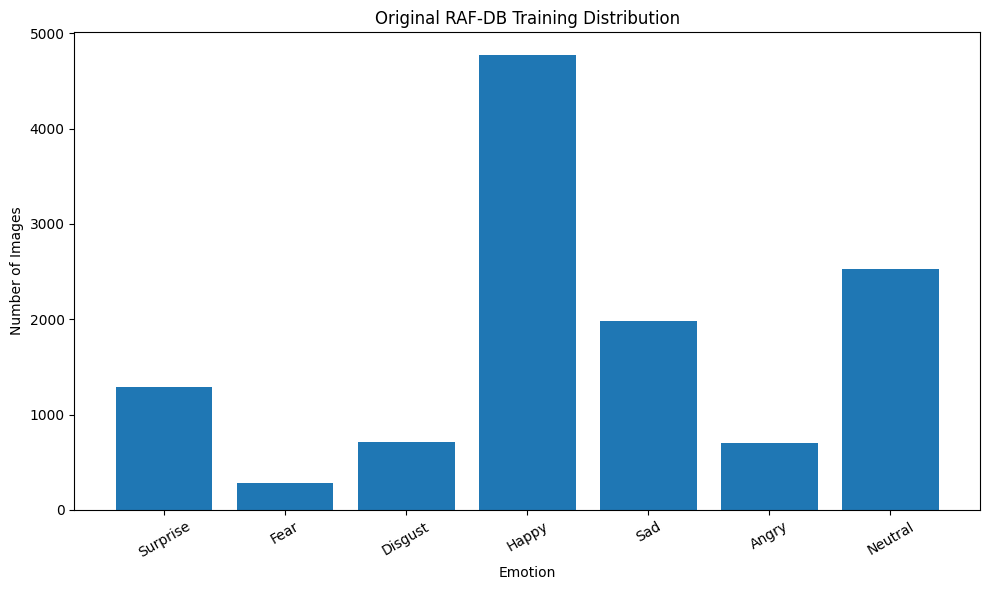

In [19]:
# ============================================================
# CHECK ORIGINAL CLASS DISTRIBUTION
# ============================================================

original_distribution = (full_train_df["emotion"].value_counts().reindex(CLASS_NAMES))

# Display counts
print(original_distribution)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(original_distribution.index,
    original_distribution.values)

plt.title("Original RAF-DB Training Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CREATE STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================================

# Split the original training dataset into:
#
# 85% -> training
# 15% -> validation
#
# Stratification ensures every emotion is represented
# proportionally in both datasets.

train_df, val_df = train_test_split(full_train_df,
    test_size=0.15, stratify=full_train_df["emotion"],
    random_state=42)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Display sizes
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 10430
Validation images: 1841
Test images: 3068


In [22]:
# ============================================================
# VERIFY TRAIN / VALIDATION DATAFRAMES
# ============================================================

print("Training columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTraining emotion distribution:")
print(train_df["emotion"].value_counts().reindex(CLASS_NAMES))

print("\nValidation emotion distribution:")
print(val_df["emotion"].value_counts().reindex(CLASS_NAMES))

Training columns:
['filepath', 'label', 'emotion']

Validation columns:
['filepath', 'label', 'emotion']

Training emotion distribution:
emotion
Surprise    1097
Fear         239
Disgust      609
Happy       4056
Sad         1685
Angry        599
Neutral     2145
Name: count, dtype: int64

Validation emotion distribution:
emotion
Surprise    193
Fear         42
Disgust     108
Happy       716
Sad         297
Angry       106
Neutral     379
Name: count, dtype: int64


In [23]:
# ============================================================
# BALANCE TRAINING DATA USING OVERSAMPLING
# ============================================================

# Find the number of samples in the largest class
max_samples = (train_df["emotion"].value_counts().max())
print("Largest class size:", max_samples)
# Store balanced class dataframes
balanced_parts = []
# Process each emotion in our fixed order
for emotion in CLASS_NAMES:

    # Select images belonging to this emotion
    class_df = train_df[train_df["emotion"] == emotion]
    # Current number of images
    current_count = len(class_df)

    print(f"{emotion:10s}: "f"{current_count} -> "f"{max_samples}")

    # Oversample minority classes
    #
    # replace=True means that an image can be
    # selected more than once.
    balanced_class_df = class_df.sample(n=max_samples,
        replace=True, random_state=42)
    # Store balanced class
    balanced_parts.append(balanced_class_df)

# Combine all classes
balanced_train_df = pd.concat(balanced_parts, ignore_index=True)

# Shuffle the complete dataset
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nBalanced training size:", len(balanced_train_df))

Largest class size: 4056
Surprise  : 1097 -> 4056
Fear      : 239 -> 4056
Disgust   : 609 -> 4056
Happy     : 4056 -> 4056
Sad       : 1685 -> 4056
Angry     : 599 -> 4056
Neutral   : 2145 -> 4056

Balanced training size: 28392


emotion
Surprise    4056
Fear        4056
Disgust     4056
Happy       4056
Sad         4056
Angry       4056
Neutral     4056
Name: count, dtype: int64


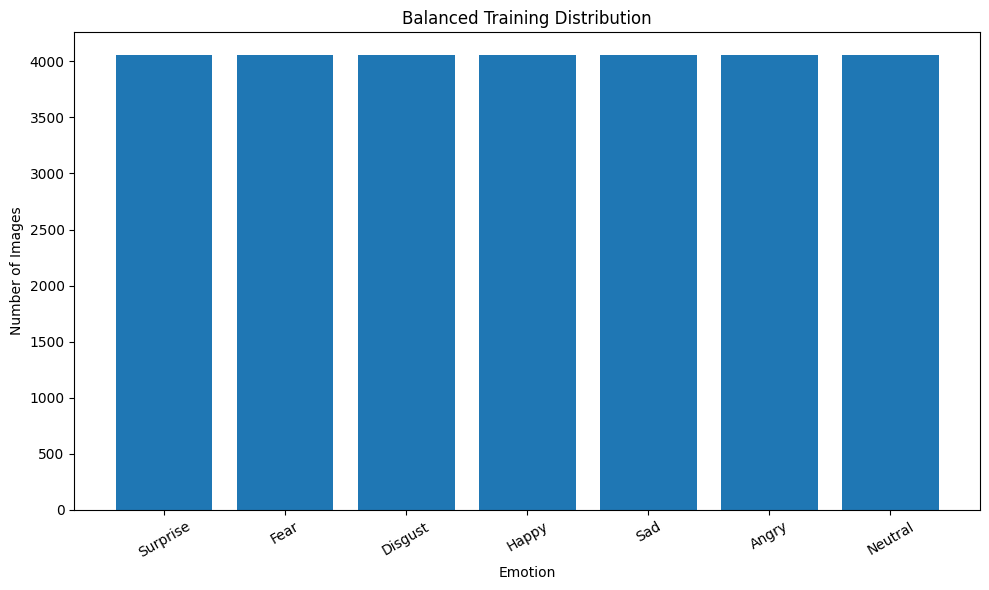

In [24]:
# ============================================================
# VERIFY BALANCED DATASET
# ============================================================

balanced_distribution = (balanced_train_df["emotion"]
    .value_counts().reindex(CLASS_NAMES))

print(balanced_distribution)
# Plot balanced distribution
plt.figure(figsize=(10, 6))

plt.bar(balanced_distribution.index,
    balanced_distribution.values)

plt.title("Balanced Training Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [27]:
# ==================================================
# Hyperparameters
# ==================================================
# Input image size required by both models
IMG_SIZE = 224

# Batch size
BATCH_SIZE = 32

# Number of epochs for initial training
BASE_EPOCHS = 15

# Number of epochs for fine tuning
FINE_TUNE_EPOCHS = 10

# Number of classes
NUM_CLASSES = 7

In [28]:
# ============================================================
# 14. MOBILENETV2 DATA GENERATORS
# ============================================================

# Training augmentation
mobilenet_train_datagen = ImageDataGenerator(
    # MobileNetV2 preprocessing
    preprocessing_function=preprocess_input,
    # Small rotation
    rotation_range=10,
    # Small horizontal shift
    width_shift_range=0.08,
    # Small vertical shift
    height_shift_range=0.08,
    # Small zoom
    zoom_range=0.10,
    # Horizontal flip
    horizontal_flip=True)

# Validation and testing
# No augmentation is applied here.
mobilenet_eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [29]:
# ============================================================
# MOBILE NET V2 TRAINING GENERATOR
# ============================================================

mobilenet_train_generator = (mobilenet_train_datagen.flow_from_dataframe(
        # Balanced training dataframe
        dataframe=balanced_train_df,
        # Column containing image paths
        x_col="filepath",
        y_col="emotion",
        # Image dimensions
        target_size=(IMG_SIZE, IMG_SIZE),
        # Batch size
        batch_size=BATCH_SIZE,
        # Seven-class classification
        class_mode="categorical",
        # Explicit class order
        classes=CLASS_NAMES,
        # Shuffle training data
        shuffle=True,
        # Reproducibility
        seed=42))

Found 28392 validated image filenames belonging to 7 classes.


In [30]:
# ============================================================
# MOBILENETV2 VALIDATION GENERATOR
# ============================================================

mobilenet_val_generator = (mobilenet_eval_datagen.flow_from_dataframe(

        # Original, unbalanced validation set
        dataframe=val_df,
        # Image path column
        x_col="filepath",
        # Emotion label column
        y_col="emotion",

        # Image dimensions
        target_size=(IMG_SIZE, IMG_SIZE),
        # Batch size
        batch_size=BATCH_SIZE,
        # Seven-class classification
        class_mode="categorical",
        # Same class order as training
        classes=CLASS_NAMES,
        # Do not shuffle validation data
        shuffle=False))

Found 1841 validated image filenames belonging to 7 classes.


In [31]:
# ============================================================
# MOBILENETV2 TEST GENERATOR
# ============================================================

mobilenet_test_generator = (mobilenet_eval_datagen.flow_from_dataframe(

        # Official RAF-DB test set
        dataframe=test_df,
        # Image path column
        x_col="filepath",
        # Emotion label column
        y_col="emotion",
        # Image dimensions
        target_size=(IMG_SIZE, IMG_SIZE),
        # Batch size
        batch_size=BATCH_SIZE,
        # Seven-class classification
        class_mode="categorical",
        # Same class order
        classes=CLASS_NAMES,
        # Do not shuffle test data
        shuffle=False))

Found 3068 validated image filenames belonging to 7 classes.


In [32]:
# ============================================================
# EFFICIENTNETB0 DATA GENERATORS
# ============================================================

# EfficientNetB0 handles its input rescaling internally.
# Therefore, no explicit preprocess_input is required here.

efficientnet_train_datagen = ImageDataGenerator(
    # Small rotation
    rotation_range=10,
    # Small horizontal shift
    width_shift_range=0.08,
    # Small vertical shift
    height_shift_range=0.08,
    # Small zoom
    zoom_range=0.10,
    # Horizontal flip
    horizontal_flip=True)

# Validation/test generator
efficientnet_eval_datagen = ImageDataGenerator()

In [33]:
# ============================================================
# EFFICIENTNETB0 TRAINING GENERATOR
# ============================================================

efficientnet_train_generator = (efficientnet_train_datagen.flow_from_dataframe(
        dataframe=balanced_train_df, x_col="filepath", y_col="emotion",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="categorical",
        classes=CLASS_NAMES, shuffle=True, seed=42))

Found 28392 validated image filenames belonging to 7 classes.


In [34]:
# ============================================================
# EFFICIENTNETB0 VALIDATION GENERATOR
# ============================================================

efficientnet_val_generator = (efficientnet_eval_datagen.flow_from_dataframe(
        dataframe=val_df, x_col="filepath", y_col="emotion",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="categorical", classes=CLASS_NAMES,
        shuffle=False))

Found 1841 validated image filenames belonging to 7 classes.


In [36]:
# ============================================================
# EFFICIENTNETB0 TEST GENERATOR
# ============================================================

efficientnet_test_generator = (efficientnet_eval_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col="filepath",
        y_col="emotion",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=CLASS_NAMES,
        shuffle=False))

Found 3068 validated image filenames belonging to 7 classes.


In [37]:
# ============================================================
# FINAL DATA PIPELINE CHECK
# ============================================================

print("MobileNetV2 class mapping:")
print(mobilenet_train_generator.class_indices)

print("\nEfficientNetB0 class mapping:")
print(efficientnet_train_generator.class_indices)

print("\nTraining samples:")
print(mobilenet_train_generator.samples)

print("\nValidation samples:")
print(mobilenet_val_generator.samples)

print("\nTest samples:")
print(mobilenet_test_generator.samples)

MobileNetV2 class mapping:
{'Surprise': 0, 'Fear': 1, 'Disgust': 2, 'Happy': 3, 'Sad': 4, 'Angry': 5, 'Neutral': 6}

EfficientNetB0 class mapping:
{'Surprise': 0, 'Fear': 1, 'Disgust': 2, 'Happy': 3, 'Sad': 4, 'Angry': 5, 'Neutral': 6}

Training samples:
28392

Validation samples:
1841

Test samples:
3068


In [40]:
# ============================================================
# TRAINING CALLBACKS
# ============================================================

# Early stopping:
# Stop training if validation loss does not improve.
early_stopping = EarlyStopping(monitor="val_loss",
    patience=4, restore_best_weights=True, verbose=1)

# Reduce learning rate when validation loss stops improving.
reduce_lr = ReduceLROnPlateau(monitor="val_loss",
    factor=0.2, patience=2, min_lr=1e-7, verbose=1)

## MobileNetV2 Model

In [41]:
# ============================================================
# BUILD MOBILENETV2 BASE MODEL
# ============================================================

mobilenet_base = MobileNetV2(weights="imagenet", include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))


# Freeze the complete pretrained backbone.
mobilenet_base.trainable = False
# Input comes from the pretrained network.
x = mobilenet_base.output
# Convert feature maps into a single feature vector.
x = GlobalAveragePooling2D()(x)
# Regularization
x = Dropout(0.4)(x)
# Seven emotion classes
output = Dense(NUM_CLASSES, activation="softmax", name="emotion_output")(x)
# Create complete model
mobilenet_model = Model(inputs=mobilenet_base.input, outputs=output)


# Compile model
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3), loss="categorical_crossentropy",
    metrics=["accuracy"])
# Display architecture
mobilenet_model.summary()

I0000 00:00:1786173855.931115     989 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786173855.936500     989 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
# ============================================================
# TRAIN MOBILENETV2 BASE MODEL
# ============================================================

mobilenet_base_history = mobilenet_model.fit(mobilenet_train_generator,
    validation_data=mobilenet_val_generator, epochs=BASE_EPOCHS,
    callbacks=[early_stopping, reduce_lr])

Epoch 1/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.4083 - loss: 1.6092

2026-08-08 07:32:41.793163: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 07:32:41.928791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


888/888 ━━━━━━━━━━━━━━━━━━━━ 312s 352ms/step - accuracy: 0.4236 - loss: 1.5674 - val_accuracy: 0.5274 - val_loss: 1.3293 - learning_rate: 0.0010
Epoch 2/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 303s 341ms/step - accuracy: 0.4513 - loss: 1.4829 - val_accuracy: 0.5062 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 3/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4640 - loss: 1.4529
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
888/888 ━━━━━━━━━━━━━━━━━━━━ 293s 330ms/step - accuracy: 0.4606 - loss: 1.4615 - val_accuracy: 0.5372 - val_loss: 1.3294 - learning_rate: 0.0010
Epoch 4/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 296s 333ms/step - accuracy: 0.4750 - loss: 1.4174 - val_accuracy: 0.5117 - val_loss: 1.3738 - learning_rate: 2.0000e-04
Epoch 5/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4776 - loss: 1.4076
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
888/888 ━━━━━━━━━━━━━━━━━━━━ 297s 334ms/step - accuracy: 0.4782 

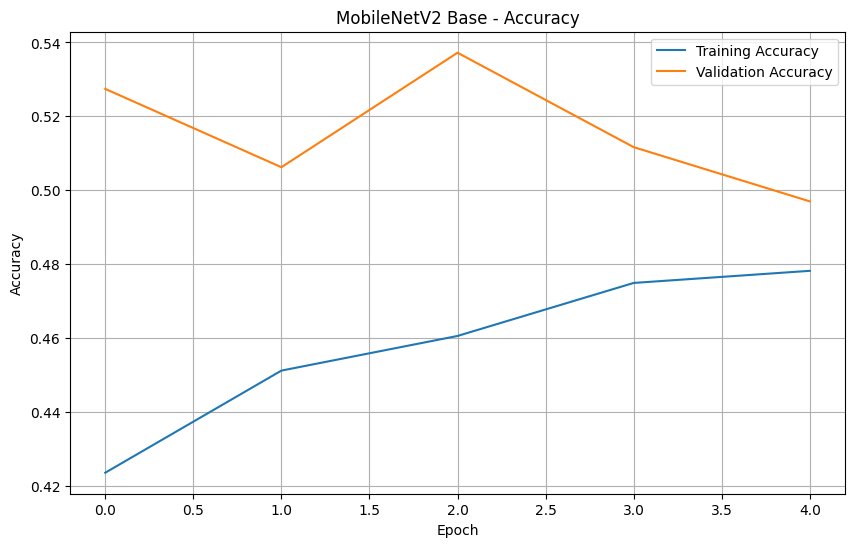

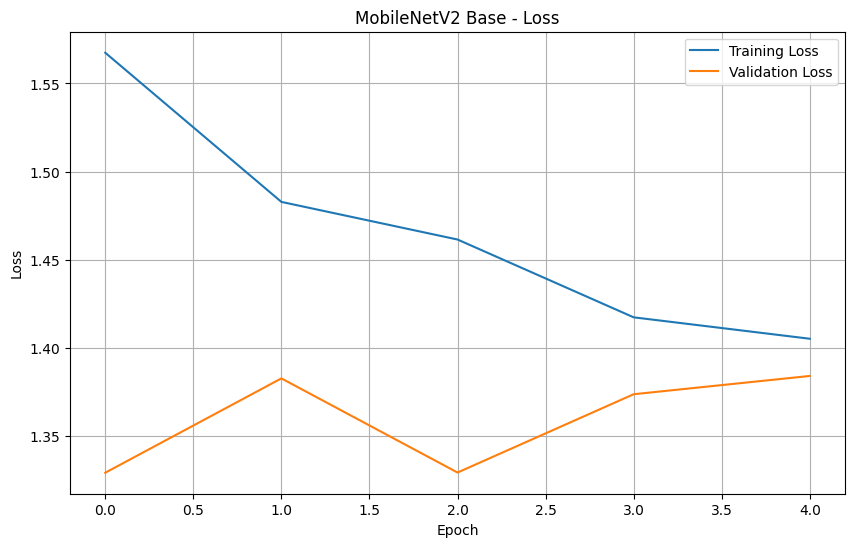

In [44]:
# ============================================================
# MOBILENETV2 BASE TRAINING HISTORY
# ============================================================
history = mobilenet_base_history.history
# -------------------------------
# Accuracy
# -------------------------------

plt.figure(figsize=(10, 6))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Base - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Loss
# -------------------------------

plt.figure(figsize=(10, 6))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Base - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# ============================================================
# EVALUATE MOBILENETV2 BASE MODEL
# ============================================================

mobilenet_base_results = mobilenet_model.evaluate(mobilenet_test_generator, verbose=1)
mobilenet_base_loss = mobilenet_base_results[0]
mobilenet_base_accuracy = mobilenet_base_results[1]
print("\nMobileNetV2 Base Model")
print("--------------------------------")
print(f"Test Loss     : {mobilenet_base_loss:.4f}")
print(f"Test Accuracy : {mobilenet_base_accuracy:.4f}")

95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5732 - loss: 1.2631

2026-08-08 07:53:19.200492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 07:53:19.337703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.5065 - loss: 1.3386

MobileNetV2 Base Model
--------------------------------
Test Loss     : 1.3386
Test Accuracy : 0.5065


In [46]:
# ============================================================
# MOBILENETV2 BASE PREDICTIONS
# ============================================================

# Generate probabilities
mobilenet_base_probabilities = (mobilenet_model.predict(mobilenet_test_generator, verbose=1))
# Convert probabilities to predicted class indices
mobilenet_base_predictions = np.argmax(mobilenet_base_probabilities, axis=1)
# True class indices
mobilenet_true_labels = (mobilenet_test_generator.classes)

96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step


In [47]:
# ============================================================
# MOBILENETV2 BASE CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("MobileNetV2 Base Model")
print("=" * 60)
print(classification_report(mobilenet_true_labels, mobilenet_base_predictions,
        target_names=CLASS_NAMES, digits=4))

MobileNetV2 Base Model
              precision    recall  f1-score   support

    Surprise     0.3835    0.6201    0.4739       329
        Fear     0.2727    0.3649    0.3121        74
     Disgust     0.3333    0.0437    0.0773       160
       Happy     0.6260    0.7359    0.6765      1185
         Sad     0.3845    0.4665    0.4216       478
       Angry     0.4058    0.3457    0.3733       162
     Neutral     0.5410    0.2426    0.3350       680

    accuracy                         0.5065      3068
   macro avg     0.4210    0.4028    0.3814      3068
weighted avg     0.5081    0.5065    0.4833      3068



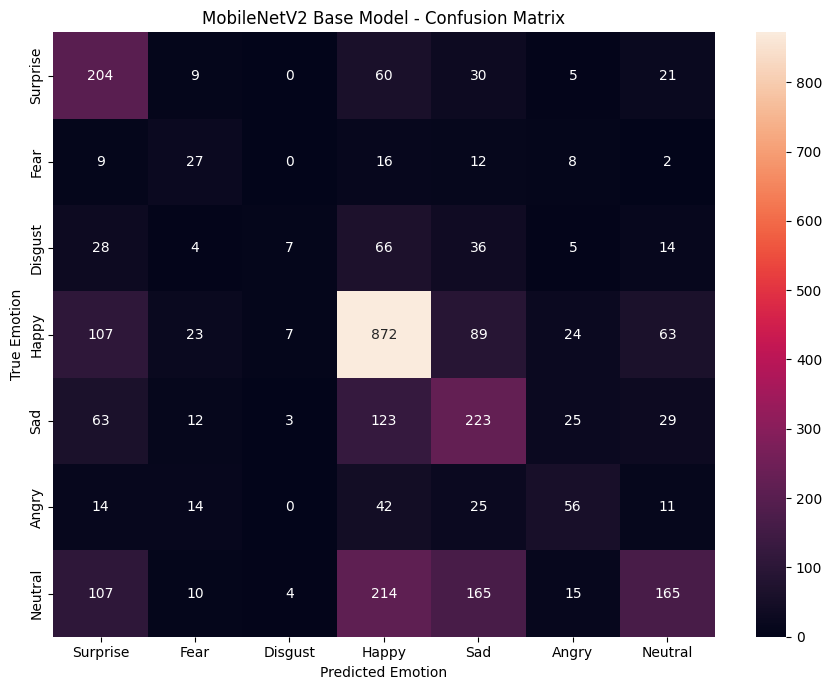

In [48]:
# ============================================================
# MOBILENETV2 BASE CONFUSION MATRIX
# ============================================================

cm_mobilenet_base = confusion_matrix(mobilenet_true_labels, mobilenet_base_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_mobilenet_base, annot=True, fmt="d", xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES)
plt.title("MobileNetV2 Base Model - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

## Fine Tuning MobileNetV2

In [49]:
# ============================================================
# FINE-TUNE MOBILENETV2
# ============================================================

# Unfreeze the MobileNetV2 backbone
mobilenet_base.trainable = True
# Freeze the earlier layers.
#
# Early layers learn generic features such as:
# edges, textures and simple shapes.
#
# Later layers learn more task-specific features.
fine_tune_from = 100
for layer in mobilenet_base.layers[ :fine_tune_from]:

    layer.trainable = False

mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy", metrics=["accuracy"])
print("Trainable layers:", sum(layer.trainable for layer in mobilenet_model.layers))

Trainable layers: 57


In [50]:
# ============================================================
# TRAIN FINE-TUNED MOBILENETV2
# ============================================================

mobilenet_finetune_history = mobilenet_model.fit(mobilenet_train_generator,
    validation_data=mobilenet_val_generator, epochs=5, 
    callbacks=[early_stopping, reduce_lr])

Epoch 1/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 340s 359ms/step - accuracy: 0.4015 - loss: 1.6175 - val_accuracy: 0.5296 - val_loss: 1.2896 - learning_rate: 1.0000e-05
Epoch 2/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 298s 336ms/step - accuracy: 0.5326 - loss: 1.2564 - val_accuracy: 0.5693 - val_loss: 1.1616 - learning_rate: 1.0000e-05
Epoch 3/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 297s 334ms/step - accuracy: 0.6010 - loss: 1.0845 - val_accuracy: 0.5964 - val_loss: 1.0980 - learning_rate: 1.0000e-05
Epoch 4/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 298s 336ms/step - accuracy: 0.6561 - loss: 0.9407 - val_accuracy: 0.6165 - val_loss: 1.0569 - learning_rate: 1.0000e-05
Epoch 5/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 300s 338ms/step - accuracy: 0.7053 - loss: 0.8154 - val_accuracy: 0.6149 - val_loss: 1.0659 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 4.


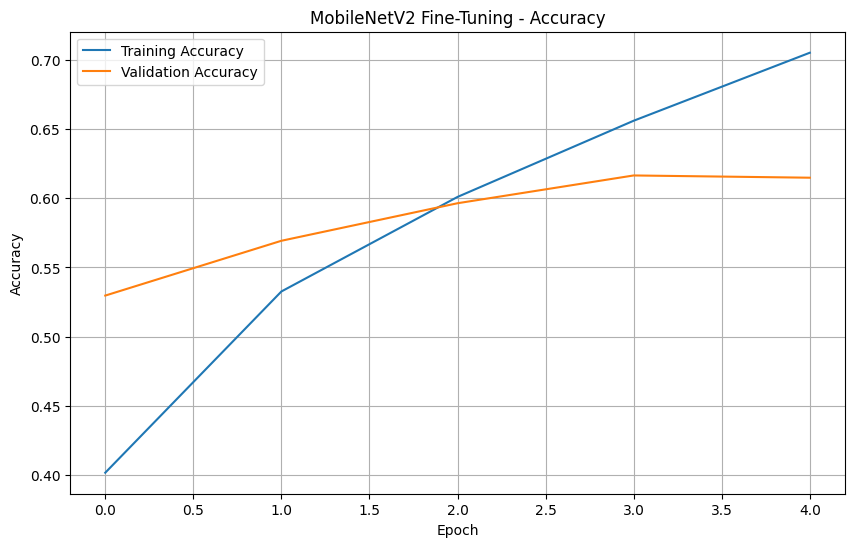

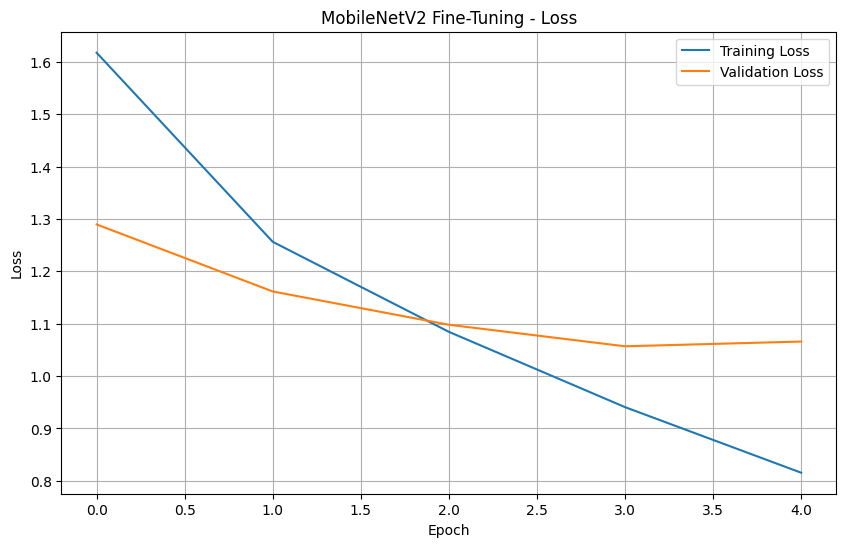

In [51]:
# ============================================================
# MOBILENETV2 FINE-TUNING HISTORY
# ============================================================

history = mobilenet_finetune_history.history
# -------------------------------
# Accuracy
# -------------------------------

plt.figure(figsize=(10, 6))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Loss
# -------------------------------

plt.figure(figsize=(10, 6))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# ============================================================
# EVALUATE FINE-TUNED MOBILENETV2
# ============================================================

mobilenet_finetune_results = (mobilenet_model.evaluate(
        mobilenet_test_generator, verbose=1))
mobilenet_finetune_loss = (mobilenet_finetune_results[0])
mobilenet_finetune_accuracy = (mobilenet_finetune_results[1])
print("\nFine-Tuned MobileNetV2")
print("--------------------------------")
print(f"Test Loss     : " f"{mobilenet_finetune_loss:.4f}")
print(f"Test Accuracy : " f"{mobilenet_finetune_accuracy:.4f}")

96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.6111 - loss: 1.0722

Fine-Tuned MobileNetV2
--------------------------------
Test Loss     : 1.0722
Test Accuracy : 0.6111


In [53]:
# ============================================================
# FINE-TUNED MOBILENETV2 PREDICTIONS
# ============================================================

mobilenet_finetune_probabilities = (mobilenet_model.predict(
        mobilenet_test_generator, verbose=1))

mobilenet_finetune_predictions = np.argmax(mobilenet_finetune_probabilities, axis=1)

96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step


In [54]:
# ============================================================
# FINE-TUNED MOBILENETV2 CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("Fine-Tuned MobileNetV2 Model")
print("=" * 60)
mobilenet_finetune_report = classification_report(mobilenet_true_labels,
    mobilenet_finetune_predictions, target_names=CLASS_NAMES,
    digits=4, output_dict=True)
print(classification_report(mobilenet_true_labels, mobilenet_finetune_predictions,
        target_names=CLASS_NAMES, digits=4))

Fine-Tuned MobileNetV2 Model
              precision    recall  f1-score   support

    Surprise     0.6429    0.6292    0.6359       329
        Fear     0.3150    0.5405    0.3980        74
     Disgust     0.2328    0.4437    0.3054       160
       Happy     0.8937    0.6743    0.7686      1185
         Sad     0.5255    0.5816    0.5521       478
       Angry     0.3759    0.6173    0.4673       162
     Neutral     0.6080    0.5588    0.5824       680

    accuracy                         0.6111      3068
   macro avg     0.5134    0.5779    0.5300      3068
weighted avg     0.6704    0.6111    0.6304      3068



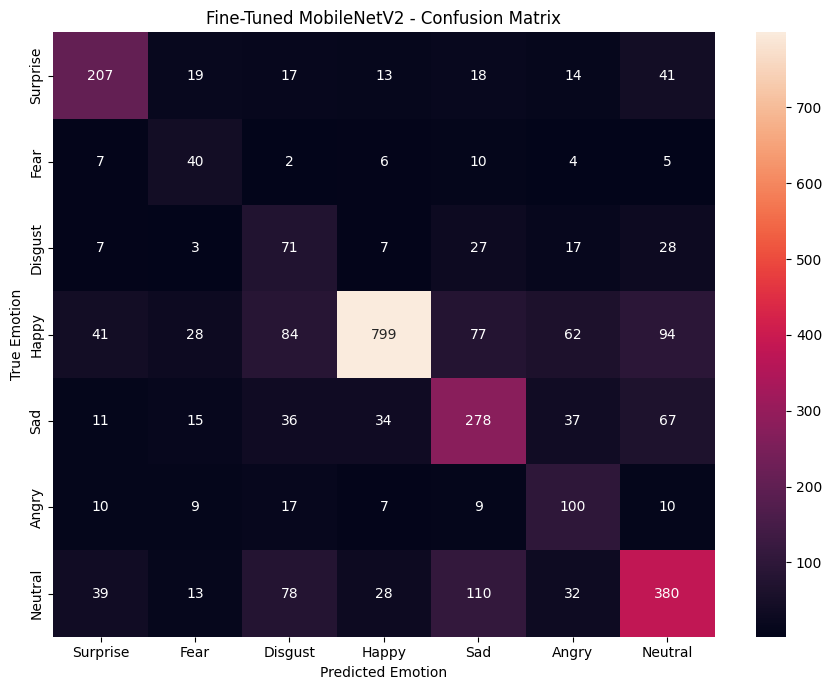

In [55]:
# ============================================================
# FINE-TUNED MOBILENETV2 CONFUSION MATRIX
# ============================================================

cm_mobilenet_finetune = confusion_matrix(mobilenet_true_labels, mobilenet_finetune_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_mobilenet_finetune, annot=True,
    fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

plt.title("Fine-Tuned MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

## EfficientNetB0 Model

In [56]:
# ============================================================
# 38. BUILD EFFICIENTNETB0 BASE MODEL
# ============================================================

efficientnet_base = EfficientNetB0(weights="imagenet",
    include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze pretrained backbone
efficientnet_base.trainable = False

# Extract feature maps
x = efficientnet_base.output

# Global average pooling
x = GlobalAveragePooling2D()(x)

# Dropout regularization
x = Dropout(0.4)(x)

# Seven-class output
output = Dense(NUM_CLASSES, activation="softmax", name="emotion_output")(x)

# Create model
efficientnet_model = Model(inputs=efficientnet_base.input,
    outputs=output)

# Compile
efficientnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy", metrics=["accuracy"])
efficientnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [57]:
# ============================================================
# TRAIN EFFICIENTNETB0 BASE MODEL
# ============================================================

efficientnet_base_history = (efficientnet_model.fit(
        efficientnet_train_generator, validation_data=efficientnet_val_generator,
        epochs=BASE_EPOCHS, callbacks=[early_stopping, reduce_lr]))

Epoch 1/15


2026-08-08 08:26:12.889203: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:26:13.032253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:26:13.383601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:26:13.524027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:26:14.322775: E external/local_xla/xla/stream_

334/888 ━━━━━━━━━━━━━━━━━━━━ 3:02 329ms/step - accuracy: 0.2902 - loss: 1.7950

2026-08-08 08:28:15.220304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:28:15.356336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:28:15.671408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:28:15.812522: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:28:16.617870: E external/local_xla/xla/stream_

888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.3479 - loss: 1.6827

2026-08-08 08:31:39.280044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:31:39.419462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:31:39.750299: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:31:39.891113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:31:40.675755: E external/local_xla/xla/stream_

888/888 ━━━━━━━━━━━━━━━━━━━━ 346s 364ms/step - accuracy: 0.4075 - loss: 1.5602 - val_accuracy: 0.4851 - val_loss: 1.4199 - learning_rate: 0.0010
Epoch 2/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.4834 - loss: 1.3951
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
888/888 ━━━━━━━━━━━━━━━━━━━━ 289s 325ms/step - accuracy: 0.4858 - loss: 1.3843 - val_accuracy: 0.5606 - val_loss: 1.2670 - learning_rate: 0.0010
Epoch 3/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 289s 325ms/step - accuracy: 0.5110 - loss: 1.3299 - val_accuracy: 0.5388 - val_loss: 1.2934 - learning_rate: 2.0000e-04
Epoch 4/15
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.5081 - loss: 1.3311
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
888/888 ━━━━━━━━━━━━━━━━━━━━ 289s 326ms/step - accuracy: 0.5124 - loss: 1.3225 - val_accuracy: 0.5399 - val_loss: 1.2931 - learning_rate: 2.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the bes

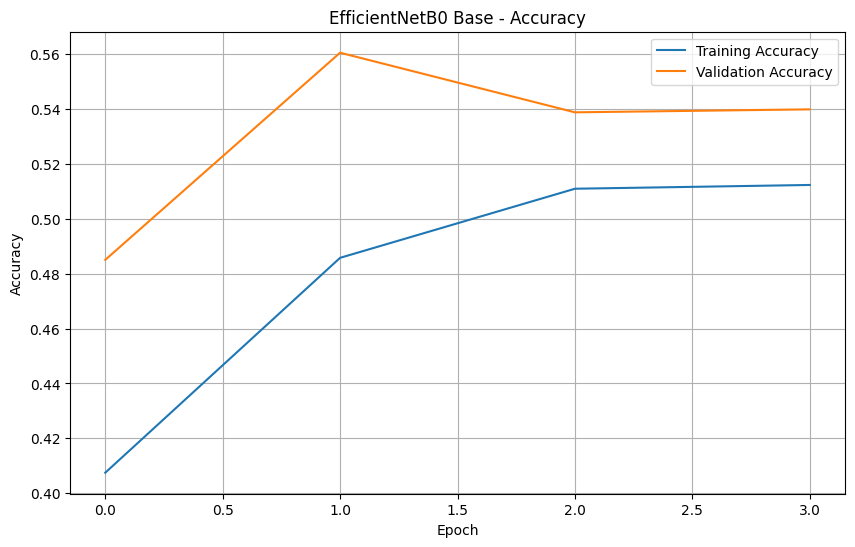

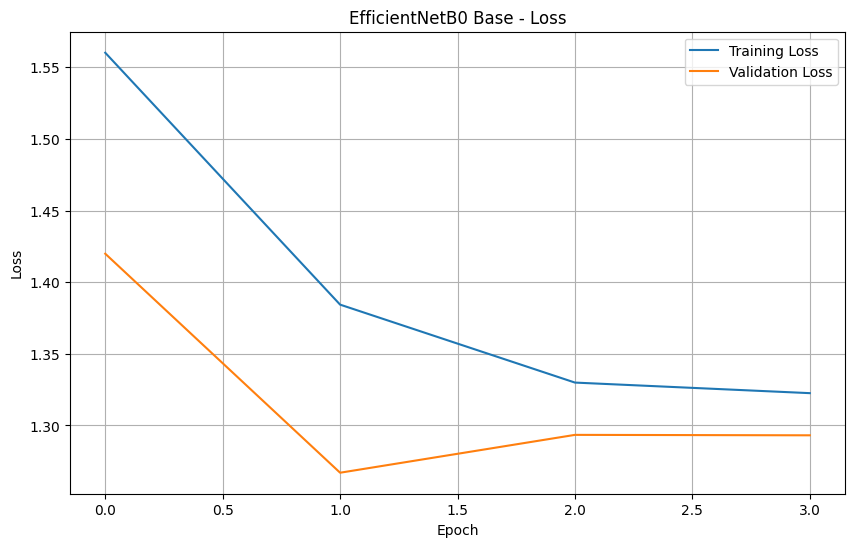

In [58]:
# ============================================================
# EFFICIENTNETB0 BASE TRAINING HISTORY
# ============================================================

history = efficientnet_base_history.history


# Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Base - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 6))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Base - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# ============================================================
# EVALUATE EFFICIENTNETB0 BASE MODEL
# ============================================================

efficientnet_base_results = (efficientnet_model.evaluate(
        efficientnet_test_generator, verbose=1))

efficientnet_base_loss = (efficientnet_base_results[0])
efficientnet_base_accuracy = (efficientnet_base_results[1])
print("\nEfficientNetB0 Base Model")
print("--------------------------------")
print(f"Test Loss     : " f"{efficientnet_base_loss:.4f}")
print(f"Test Accuracy : " f"{efficientnet_base_accuracy:.4f}")

95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5456 - loss: 1.3267

2026-08-08 08:47:50.402821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:47:50.544292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:47:50.891973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:47:51.032424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 08:47:51.803670: E external/local_xla/xla/stream_

96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.4703 - loss: 1.4243

EfficientNetB0 Base Model
--------------------------------
Test Loss     : 1.4243
Test Accuracy : 0.4703


In [60]:
# ============================================================
# EFFICIENTNETB0 BASE PREDICTIONS
# ============================================================

efficientnet_base_probabilities = (efficientnet_model.predict(
        efficientnet_test_generator, verbose=1))
efficientnet_base_predictions = np.argmax(efficientnet_base_probabilities, axis=1)
efficientnet_true_labels = (efficientnet_test_generator.classes)

96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step


In [61]:
# ============================================================
# EFFICIENTNETB0 BASE CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("EfficientNetB0 Base Model")
print("=" * 60)
print(classification_report(efficientnet_true_labels,
        efficientnet_base_predictions, target_names=CLASS_NAMES, digits=4))

EfficientNetB0 Base Model
              precision    recall  f1-score   support

    Surprise     0.4326    0.6049    0.5044       329
        Fear     0.1592    0.6216    0.2534        74
     Disgust     0.1529    0.5312    0.2374       160
       Happy     0.8045    0.5384    0.6451      1185
         Sad     0.4429    0.4540    0.4483       478
       Angry     0.5070    0.2222    0.3090       162
     Neutral     0.5428    0.3265    0.4077       680

    accuracy                         0.4703      3068
   macro avg     0.4346    0.4713    0.4008      3068
weighted avg     0.5850    0.4703    0.4983      3068



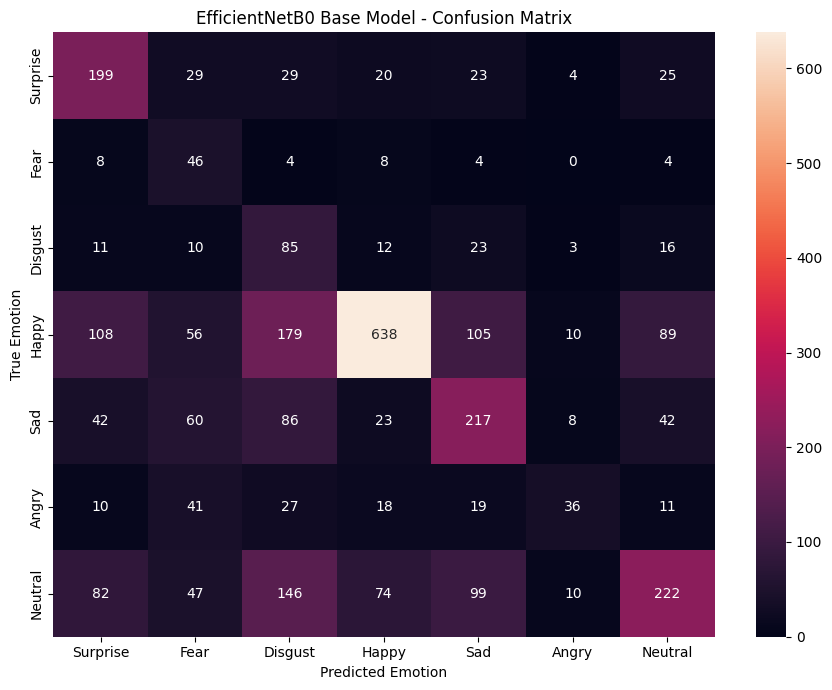

In [62]:
# ============================================================
# EFFICIENTNETB0 BASE CONFUSION MATRIX
# ============================================================

cm_efficientnet_base = confusion_matrix(efficientnet_true_labels,
    efficientnet_base_predictions)
plt.figure(figsize=(9, 7))

sns.heatmap(cm_efficientnet_base, annot=True, fmt="d",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("EfficientNetB0 Base Model - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

## Fine-Tuned EfficientNetB0

In [63]:
# ============================================================
# FINE-TUNE EFFICIENTNETB0
# ============================================================

# Unfreeze EfficientNet
efficientnet_base.trainable = True
# Freeze earlier layers
# EfficientNetB0 has fewer layers than some larger
# architectures, so we keep the earlier feature
# extraction layers frozen.
fine_tune_from = 200
for layer in efficientnet_base.layers[ :fine_tune_from]:
    layer.trainable = False

# Recompile with a very small learning rate
efficientnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy", metrics=["accuracy"])
print("Trainable layers:", sum(layer.trainable for layer in efficientnet_model.layers))

Trainable layers: 41


In [64]:
# ============================================================
# TRAIN FINE-TUNED EFFICIENTNETB0
# ============================================================

efficientnet_finetune_history = (efficientnet_model.fit(efficientnet_train_generator,
        validation_data=efficientnet_val_generator, epochs=5,
        callbacks=[early_stopping, reduce_lr]))

Epoch 1/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 342s 355ms/step - accuracy: 0.4174 - loss: 1.5411 - val_accuracy: 0.4666 - val_loss: 1.4765 - learning_rate: 1.0000e-05
Epoch 2/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4831 - loss: 1.3776
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
888/888 ━━━━━━━━━━━━━━━━━━━━ 292s 328ms/step - accuracy: 0.4986 - loss: 1.3465 - val_accuracy: 0.5301 - val_loss: 1.3139 - learning_rate: 1.0000e-05
Epoch 3/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 292s 329ms/step - accuracy: 0.5301 - loss: 1.2729 - val_accuracy: 0.5432 - val_loss: 1.2937 - learning_rate: 2.0000e-06
Epoch 4/5
888/888 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5382 - loss: 1.2508
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
888/888 ━━━━━━━━━━━━━━━━━━━━ 296s 333ms/step - accuracy: 0.5388 - loss: 1.2445 - val_accuracy: 0.5502 - val_loss: 1.2542 - learning_rate: 2.0000e-06
Epoch 4: early stopping
Restoring model weights from the 

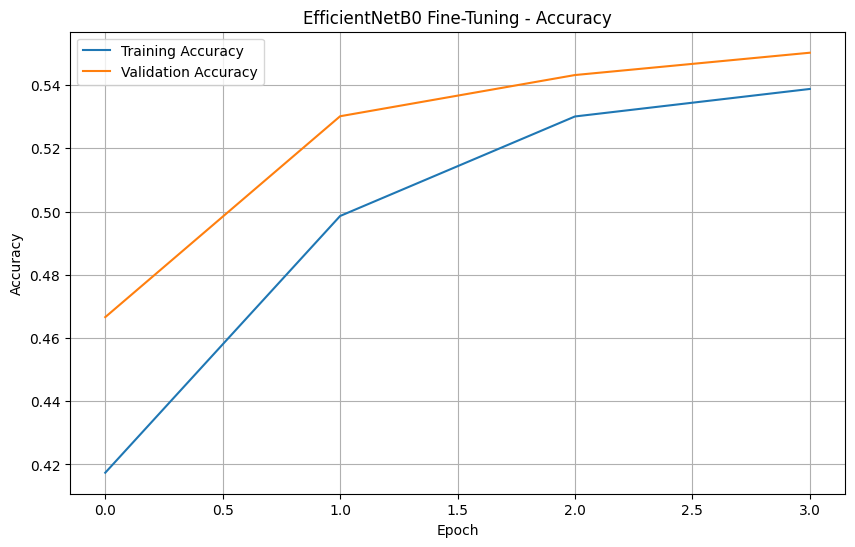

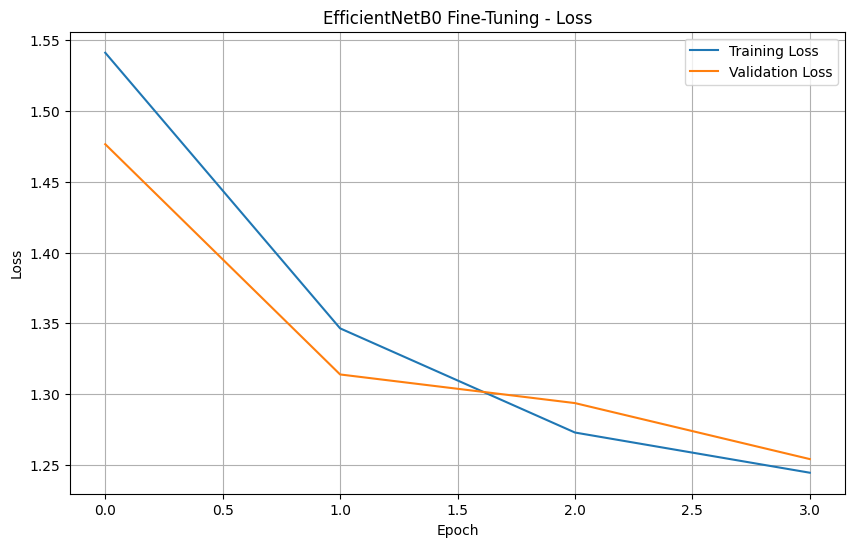

In [65]:
# ============================================================
# EFFICIENTNETB0 FINE-TUNING HISTORY
# ============================================================

history = efficientnet_finetune_history.history

# Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 6))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
# ============================================================
# EVALUATE FINE-TUNED EFFICIENTNETB0
# ============================================================
efficientnet_finetune_results = (efficientnet_model.evaluate(efficientnet_test_generator,
        verbose=1))
efficientnet_finetune_loss = (efficientnet_finetune_results[0])
efficientnet_finetune_accuracy = (efficientnet_finetune_results[1])
print("\nFine-Tuned EfficientNetB0")
print("--------------------------------")
print(f"Test Loss     : " f"{efficientnet_finetune_loss:.4f}")
print(f"Test Accuracy : " f"{efficientnet_finetune_accuracy:.4f}")

96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.4795 - loss: 1.4594

Fine-Tuned EfficientNetB0
--------------------------------
Test Loss     : 1.4594
Test Accuracy : 0.4795


In [67]:
# ============================================================
# FINE-TUNED EFFICIENTNETB0 PREDICTIONS
# ============================================================

efficientnet_finetune_probabilities = (efficientnet_model.predict(efficientnet_test_generator,
        verbose=1))
efficientnet_finetune_predictions = np.argmax(efficientnet_finetune_probabilities, axis=1)

96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step


In [68]:
# ============================================================
# FINE-TUNED EFFICIENTNETB0 CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("Fine-Tuned EfficientNetB0")
print("=" * 60)

efficientnet_finetune_report = (classification_report(efficientnet_true_labels,
        efficientnet_finetune_predictions, target_names=CLASS_NAMES,
        digits=4, output_dict=True))

print(classification_report(efficientnet_true_labels,
        efficientnet_finetune_predictions, target_names=CLASS_NAMES,
        digits=4))

Fine-Tuned EfficientNetB0
              precision    recall  f1-score   support

    Surprise     0.4404    0.6292    0.5181       329
        Fear     0.1525    0.6081    0.2439        74
     Disgust     0.1613    0.3438    0.2196       160
       Happy     0.8816    0.4338    0.5814      1185
         Sad     0.4924    0.4749    0.4835       478
       Angry     0.3600    0.3889    0.3739       162
     Neutral     0.4845    0.5294    0.5060       680

    accuracy                         0.4795      3068
   macro avg     0.4247    0.4869    0.4181      3068
weighted avg     0.6030    0.4795    0.5047      3068



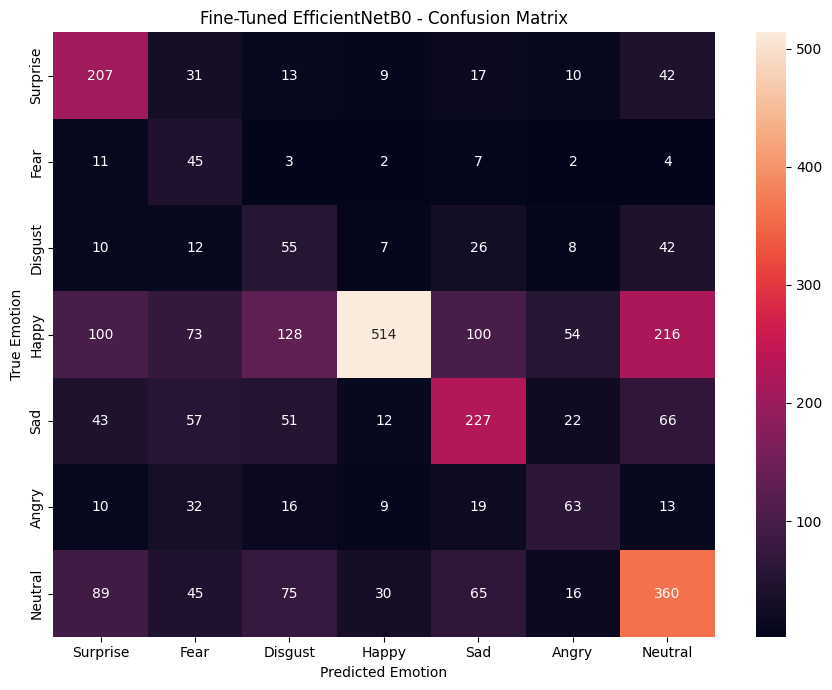

In [69]:
# ============================================================
# FINE-TUNED EFFICIENTNETB0 CONFUSION MATRIX
# ============================================================

cm_efficientnet_finetune = confusion_matrix(efficientnet_true_labels, efficientnet_finetune_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_efficientnet_finetune, annot=True, fmt="d",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Fine-Tuned EfficientNetB0 - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

## Model Comparison

In [70]:
# ============================================================
# CALCULATE MACRO F1 SCORES
# ============================================================

# MobileNetV2 Base
mobilenet_base_f1 = f1_score(mobilenet_true_labels,
    mobilenet_base_predictions, average="macro")

# MobileNetV2 Fine-Tuned
mobilenet_finetune_f1 = f1_score(mobilenet_true_labels,
    mobilenet_finetune_predictions, average="macro")

# EfficientNetB0 Base
efficientnet_base_f1 = f1_score(efficientnet_true_labels,
    efficientnet_base_predictions, average="macro")

# EfficientNetB0 Fine-Tuned
efficientnet_finetune_f1 = f1_score(efficientnet_true_labels,
    efficientnet_finetune_predictions, average="macro")

In [71]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame({"Model": [
        "MobileNetV2 Base",
        "MobileNetV2 Fine-Tuned",
        "EfficientNetB0 Base",
        "EfficientNetB0 Fine-Tuned"],

    "Test Accuracy": [
        mobilenet_base_accuracy,
        mobilenet_finetune_accuracy,
        efficientnet_base_accuracy,
        efficientnet_finetune_accuracy],

    "Macro F1": [
        mobilenet_base_f1,
        mobilenet_finetune_f1,
        efficientnet_base_f1,
        efficientnet_finetune_f1],

    "Test Loss": [
        mobilenet_base_loss,
        mobilenet_finetune_loss,
        efficientnet_base_loss,
        efficientnet_finetune_loss]})


# Sort by Macro F1
comparison_df = comparison_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)
# Display
print(comparison_df.to_string(index=False))

                    Model  Test Accuracy  Macro F1  Test Loss
   MobileNetV2 Fine-Tuned       0.611147  0.529967   1.072197
EfficientNetB0 Fine-Tuned       0.479465  0.418059   1.459441
      EfficientNetB0 Base       0.470339  0.400783   1.424323
         MobileNetV2 Base       0.506519  0.381394   1.338621


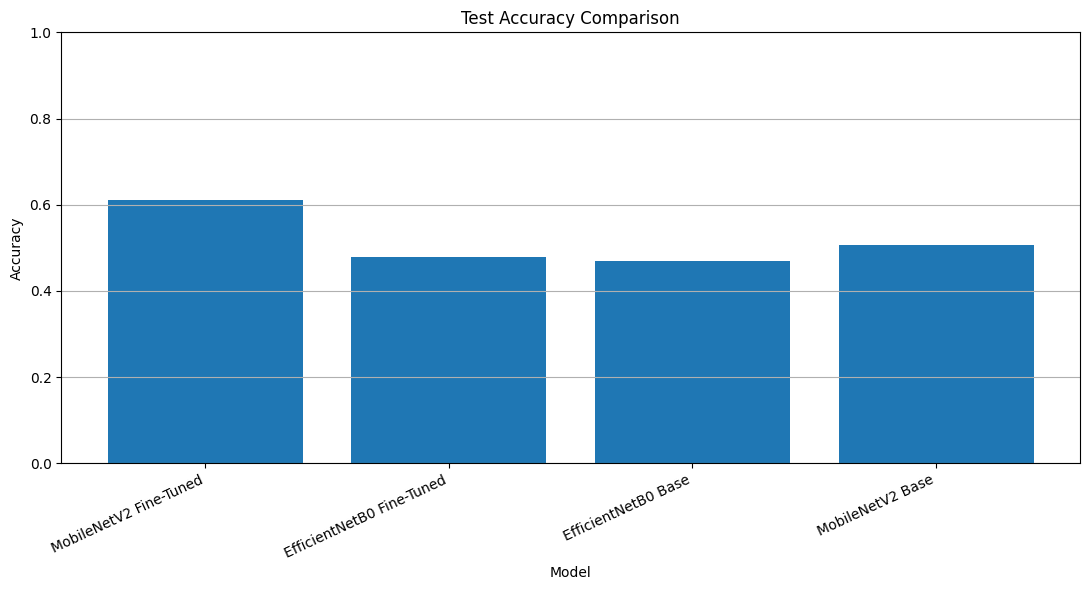

In [72]:
# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

# Select model with highest Macro F1
best_model_name = comparison_df.iloc[0]["Model"]
print("BEST MODEL:")
print(best_model_name)
print("\nSelection criterion:")
print("Highest Macro F1")

BEST MODEL:
MobileNetV2 Fine-Tuned

Selection criterion:
Highest Macro F1


In [74]:
# ============================================================
# ASSIGN BEST TRAINED MODEL
# ============================================================

if best_model_name == "MobileNetV2 Base":
    best_model = mobilenet_model
    best_generator = mobilenet_test_generator
    best_predictions = mobilenet_base_predictions
    best_probabilities = mobilenet_base_probabilities

elif best_model_name == "MobileNetV2 Fine-Tuned":
    best_model = mobilenet_model
    best_generator = mobilenet_test_generator
    best_predictions = mobilenet_finetune_predictions
    best_probabilities = mobilenet_finetune_probabilities

elif best_model_name == "EfficientNetB0 Base":
    best_model = efficientnet_model
    best_generator = efficientnet_test_generator
    best_predictions = efficientnet_base_predictions
    best_probabilities = efficientnet_base_probabilities

else:
    best_model = efficientnet_model
    best_generator = efficientnet_test_generator
    best_predictions = efficientnet_finetune_predictions
    best_probabilities = efficientnet_finetune_probabilities

print("Selected: ", best_model_name)

Selected:  MobileNetV2 Fine-Tuned


In [75]:
# ============================================================
# RANDOM IMAGE PREDICTION USING BEST MODEL
# ============================================================

import random
# Select a random test index
random_index = random.randint(0, len(test_df) - 1)
# Get image information
sample = test_df.iloc[random_index]
# Image path
image_path = sample["filepath"]
# Actual emotion
actual_emotion = sample["emotion"]

print("Image:", os.path.basename(image_path))

print("Actual Emotion:", actual_emotion)

Image: test_0201_aligned.jpg
Actual Emotion: Angry


In [76]:
# ============================================================
# LOAD RANDOM IMAGE
# ============================================================

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
# Load image
image = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))

# Convert to NumPy array
image_array = img_to_array(image)
# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# ------------------------------------------------------------
# MODEL-SPECIFIC PREPROCESSING
# ------------------------------------------------------------

if "MobileNetV2" in best_model_name:
    image_input = preprocess_input(image_array)

else:
    # EfficientNetB0 includes its preprocessing internally
    image_input = image_array

In [77]:
# ============================================================
# PREDICT RANDOM IMAGE
# ============================================================

# Generate prediction probabilities
prediction_probabilities = (best_model.predict(image_input, verbose=0))
# Get predicted class
predicted_index = np.argmax(prediction_probabilities[0])
# Get emotion name
predicted_emotion = CLASS_NAMES[predicted_index]

# Confidence
confidence = (prediction_probabilities[0][predicted_index] * 100)
print(
    "Predicted Emotion:",
    predicted_emotion
)

print(
    f"Confidence: {confidence:.2f}%"
)

2026-08-08 09:12:03.305389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 09:12:03.439154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Predicted Emotion: Angry
Confidence: 97.63%


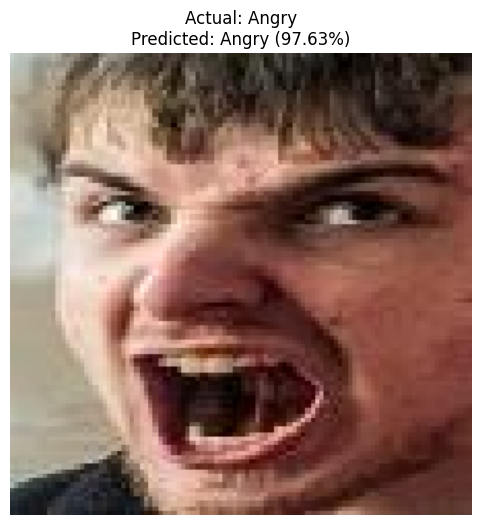

In [78]:
# ============================================================
# DISPLAY RANDOM PREDICTION
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {actual_emotion}\n"
    f"Predicted: {predicted_emotion} "
    f"({confidence:.2f}%)")

plt.show()

In [79]:
# ============================================================
# EMOTION PROBABILITY DISTRIBUTION
# ============================================================

probabilities = (prediction_probabilities[0] * 100)
probability_df = pd.DataFrame({"Emotion": CLASS_NAMES, "Probability": probabilities})
probability_df = probability_df.sort_values(by="Probability", ascending=False)
print(probability_df)

    Emotion  Probability
5     Angry    97.634598
4       Sad     1.080098
2   Disgust     0.381890
0  Surprise     0.335939
1      Fear     0.277986
3     Happy     0.201546
6   Neutral     0.087931


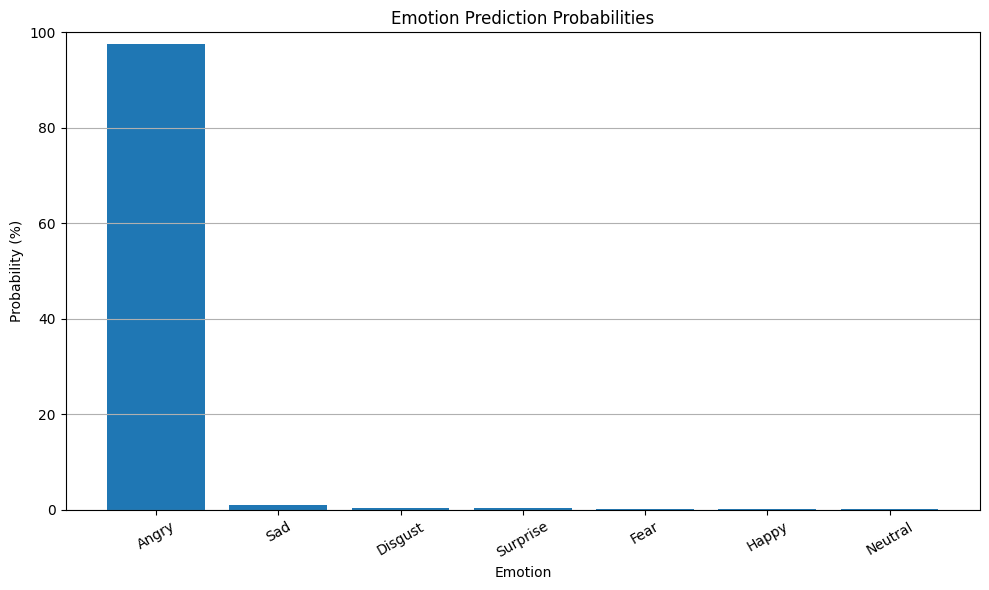

In [80]:
# ============================================================
# EMOTION PROBABILITY PLOT
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(probability_df["Emotion"],
    probability_df["Probability"])

plt.title("Emotion Prediction Probabilities")
plt.xlabel("Emotion")
plt.ylabel("Probability (%)")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.grid(axis="y")
plt.tight_layout()
plt.show()